<a href="https://colab.research.google.com/github/Ahmadtjk/Ahmadtjk/blob/main/Portfolio_Optimisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Apply Modern Portfolio Theory to a portfolio consisting of Bond, ETF, Gold, and Equity by loading their historical adjusted close price data, calculating returns and covariance, simulating portfolios to identify the efficient frontier, visualizing the efficient frontier, and summarizing the Modern Portfolio Theory model along with the characteristics of the identified optimal portfolios.

## Load Asset Data

Assume common tickers for Bond, ETF, Gold, and Equity (e.g., 'AGG' for Bond, 'SPY' for ETF, 'GLD' for Gold, and 'MSFT' for Equity) and load their historical adjusted close price data. This step will also handle any missing data or date alignment issues.


In [2]:
import yfinance as yf
import pandas as pd

# 2. Define a dictionary of asset tickers
tickers = {
    'Bond': 'AGG',  # iShares Core U.S. Aggregate Bond ETF
    'ETF': 'SPY',   # SPDR S&P 500 ETF Trust
    'Gold': 'GLD',  # SPDR Gold Shares
    'Equity': 'MSFT' # Microsoft Corporation
}

# 3. Use yfinance.download() to fetch the historical 'Close' prices for all defined tickers
# Fetch data for the last 5 years. With auto_adjust=True (new default), 'Close' is adjusted.
asset_data = yf.download(list(tickers.values()), period="5y")['Close']

# Rename columns to descriptive names
asset_data.rename(columns={v: k for k, v in tickers.items()}, inplace=True)

# 4. Handle any missing data by dropping rows with NaN values
asset_data.dropna(inplace=True)

# 5. Display the first few rows of the DataFrame and check its information
print("First 5 rows of the asset data:")
print(asset_data.head())
print("\nInformation about the asset data DataFrame:")
asset_data.info()

/tmp/ipykernel_30667/3117869030.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset_data = yf.download(list(tickers.values()), period="5y")['Close']
[*********************100%***********************]  4 of 4 completed


First 5 rows of the asset data:
Ticker           Bond        Gold      Equity         ETF
Date                                                     
2021-03-22  97.736809  163.000000  226.446472  366.672394
2021-03-23  97.986023  161.809998  227.972198  363.786469
2021-03-24  98.106346  162.369995  225.937927  361.937073
2021-03-25  98.054779  161.779999  222.944107  363.973236
2021-03-26  97.891525  162.240005  226.916656  369.838593

Information about the asset data DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-03-22 to 2026-03-20
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bond    1256 non-null   float64
 1   Gold    1256 non-null   float64
 2   Equity  1256 non-null   float64
 3   ETF     1256 non-null   float64
dtypes: float64(4)
memory usage: 49.1 KB


In [3]:
import numpy as np

# 1. Calculate daily returns
daily_returns = asset_data.pct_change().dropna()

# 2. Calculate annual returns (mean of daily returns * 252 trading days)
annual_returns = daily_returns.mean() * 252

# 3. Calculate annual covariance matrix (daily covariance * 252 trading days)
annual_cov_matrix = daily_returns.cov() * 252

# Display the first few rows of daily returns and the calculated annual returns and covariance
print("First 5 rows of Daily Returns:")
print(daily_returns.head())
print("\nAnnual Returns:")
print(annual_returns)
print("\nAnnual Covariance Matrix:")
print(annual_cov_matrix)

First 5 rows of Daily Returns:
Ticker          Bond      Gold    Equity       ETF
Date                                              
2021-03-23  0.002550 -0.007301  0.006738 -0.007871
2021-03-24  0.001228  0.003461 -0.008923 -0.005084
2021-03-25 -0.000526 -0.003634 -0.013251  0.005626
2021-03-26 -0.001665  0.002843  0.017819  0.016115
2021-03-29 -0.001669 -0.011896 -0.005243 -0.000505

Annual Returns:
Ticker
Bond      0.003720
Gold      0.202280
Equity    0.139074
ETF       0.128932
dtype: float64

Annual Covariance Matrix:
Ticker      Bond      Gold    Equity       ETF
Ticker                                        
Bond    0.003669  0.003135  0.002147  0.002009
Gold    0.003135  0.030539  0.002974  0.003592
Equity  0.002147  0.002974  0.068311  0.032929
ETF     0.002009  0.003592  0.032929  0.028867


**Reasoning**:
With the annual returns and covariance matrix calculated, the next step is to simulate a large number of portfolios to determine their expected returns, volatility (standard deviation), and Sharpe ratios. This process is crucial for visualizing the efficient frontier and identifying optimal portfolios as per Modern Portfolio Theory.



In [4]:
num_portfolios = 10000 # Number of random portfolios to simulate
num_assets = len(tickers)

# Arrays to store results
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []
sharpe_ratios = []

for portfolio in range(num_portfolios):
    # Generate random weights for each asset
    weights = np.random.random(num_assets)
    weights /= np.sum(weights) # Ensure weights sum to 1

    # Calculate portfolio return
    returns = np.sum(weights * annual_returns)

    # Calculate portfolio volatility (standard deviation)
    # The formula is sqrt(w' * Cov * w), where w' is the transpose of weights vector
    volatility = np.sqrt(np.dot(weights.T, np.dot(annual_cov_matrix, weights)))

    # Calculate Sharpe Ratio (assuming risk-free rate is 0 for simplicity, adjust as needed)
    # Sharpe Ratio = (Portfolio Return - Risk-Free Rate) / Portfolio Volatility
    sharpe_ratio = returns / volatility # Assuming risk-free rate = 0

    portfolio_returns.append(returns)
    portfolio_volatility.append(volatility)
    portfolio_weights.append(weights)
    sharpe_ratios.append(sharpe_ratio)

# Create a DataFrame to store the simulation results
portfolio_results_df = pd.DataFrame({
    'Returns': portfolio_returns,
    'Volatility': portfolio_volatility,
    'Sharpe Ratio': sharpe_ratios
})

# Add individual asset weights to the DataFrame
for counter, symbol in enumerate(tickers.keys()):
    portfolio_results_df[symbol + ' Weight'] = [w[counter] for w in portfolio_weights]

# Display the first few rows of the simulated portfolios
print("First 5 rows of Simulated Portfolios:")
print(portfolio_results_df.head())
print("\nInformation about the Simulated Portfolios DataFrame:")
portfolio_results_df.info()


First 5 rows of Simulated Portfolios:
    Returns  Volatility  Sharpe Ratio  Bond Weight  ETF Weight  Gold Weight  \
0  0.126490    0.104457      1.210932     0.247995    0.381083     0.064884   
1  0.154840    0.154086      1.004896     0.032501    0.351290     0.415209   
2  0.131317    0.138248      0.949868     0.146943    0.238880     0.321715   
3  0.077825    0.090291      0.861931     0.490269    0.121518     0.134775   
4  0.101132    0.109129      0.926728     0.342161    0.176012     0.210302   

   Equity Weight  
0       0.306038  
1       0.200999  
2       0.292462  
3       0.253438  
4       0.271524  

Information about the Simulated Portfolios DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Returns        10000 non-null  float64
 1   Volatility     10000 non-null  float64
 2   Sharpe Ratio   10000 non-null 

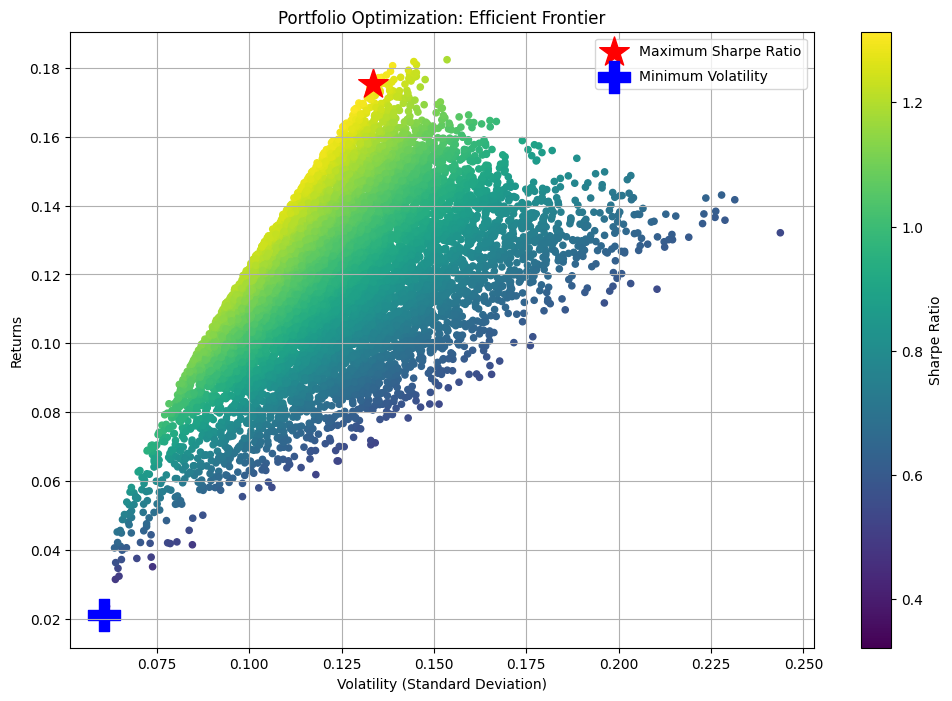


Maximum Sharpe Ratio Portfolio:
Returns          0.175241
Volatility       0.133394
Sharpe Ratio     1.313716
Bond Weight      0.002166
ETF Weight       0.632444
Gold Weight      0.018941
Equity Weight    0.346449
Name: 4476, dtype: float64

Minimum Volatility Portfolio:
Returns          0.021053
Volatility       0.060704
Sharpe Ratio     0.346820
Bond Weight      0.877752
ETF Weight       0.023173
Gold Weight      0.032186
Equity Weight    0.066890
Name: 8624, dtype: float64


In [5]:
import matplotlib.pyplot as plt

# Find the portfolio with the maximum Sharpe Ratio
max_sharpe_portfolio = portfolio_results_df.loc[portfolio_results_df['Sharpe Ratio'].idxmax()]

# Find the portfolio with the minimum Volatility
min_volatility_portfolio = portfolio_results_df.loc[portfolio_results_df['Volatility'].idxmin()]

# Create a scatter plot of all simulated portfolios
plt.figure(figsize=(12, 8))
plt.scatter(portfolio_results_df['Volatility'], portfolio_results_df['Returns'],
            c=portfolio_results_df['Sharpe Ratio'], cmap='viridis', s=20)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Returns')
plt.title('Portfolio Optimization: Efficient Frontier')
plt.grid(True)

# Plot the portfolio with the maximum Sharpe Ratio
plt.scatter(max_sharpe_portfolio['Volatility'], max_sharpe_portfolio['Returns'],
            marker='*', color='red', s=500, label='Maximum Sharpe Ratio')

# Plot the portfolio with the minimum Volatility
plt.scatter(min_volatility_portfolio['Volatility'], min_volatility_portfolio['Returns'],
            marker='P', color='blue', s=500, label='Minimum Volatility')

plt.legend(labelspacing=0.8)
plt.show()

# Display the characteristics of the optimal portfolios
print("\nMaximum Sharpe Ratio Portfolio:")
print(max_sharpe_portfolio)
print("\nMinimum Volatility Portfolio:")
print(min_volatility_portfolio)

## Final Report

Summarize the Modern Portfolio Theory model, explain the efficient frontier, and discuss the characteristics of the identified optimal portfolios (minimum volatility and maximum Sharpe ratio) for the given assets.


## Summary:

### Q&A
*   **Summarize the Modern Portfolio Theory (MPT) model:** MPT is a framework for constructing investment portfolios to maximize expected return for a given level of market risk, or equivalently, minimize risk for a given level of expected return. It emphasizes diversification, suggesting that combining different assets can reduce overall portfolio risk without necessarily sacrificing returns.
*   **Explain the efficient frontier:** The efficient frontier is a set of optimal portfolios that offer the highest possible expected return for a defined level of risk (standard deviation) or the lowest possible risk for a given level of expected return. Any portfolio that lies below the efficient frontier is considered sub-optimal because it offers less return for the same amount of risk, or the same return for more risk.
*   **Discuss the characteristics of the identified optimal portfolios (minimum volatility and maximum Sharpe ratio) for the given assets:**
    *   **Maximum Sharpe Ratio Portfolio:** This portfolio represents the best risk-adjusted return among all simulated portfolios. It aims to maximize the excess return (above a risk-free rate, though zero was assumed in this analysis) per unit of risk. Investors seeking high returns relative to the risk taken would favor this portfolio.
    *   **Minimum Volatility Portfolio:** This portfolio represents the lowest possible risk (standard deviation) among all simulated portfolios. Investors who are highly risk-averse and prioritize capital preservation would find this portfolio most appealing.

### Data Analysis Key Findings
*   Initial data loading faced a `KeyError: 'Adj Close'` from the `yfinance` library, which was resolved by using the 'Close' price column, as `yfinance` now provides adjusted prices directly in 'Close' when `auto_adjust=True`.
*   Historical adjusted close prices for 'AGG' (Bond), 'SPY' (ETF), 'GLD' (Gold), and 'MSFT' (Equity) were successfully loaded for the last 5 years, resulting in 1256 entries after dropping missing values.
*   Annual returns and the annual covariance matrix for the assets were calculated, serving as critical inputs for portfolio optimization.
*   A simulation of 10,000 random portfolios was performed, with each portfolio's returns, volatility, and Sharpe ratio computed to map out the efficient frontier.
*   Two optimal portfolios were identified: the maximum Sharpe Ratio portfolio (offering the best risk-adjusted return) and the minimum Volatility portfolio (representing the lowest risk). Their specific characteristics, including asset weights, returns, and volatility, were determined and visualized on a scatter plot representing the efficient frontier.

### Insights or Next Steps
*   The analysis successfully demonstrates how diversification among Bond, ETF, Gold, and Equity can lead to optimized portfolios that balance risk and return, highlighting the practical application of MPT.
*   Future analysis could incorporate a realistic risk-free rate, explore different investment horizons, or include additional asset classes to refine the efficient frontier and provide more nuanced investment strategies.
